A notebook for batch processing the ExoMars SKP Field Test 1 dataset into RGB products, using the fully automated '99u' (99th percentile unbalanced) stretch routine.

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'svg' # note - requires Inkscape to be installed, and to be accessible from the terminal
# on macos, add inkscape to the path with `sudo ln -s /Applications/Inkscape.app/Contents/MacOS/inkscape /usr/local/bin/inkscape`
%matplotlib inline

In [2]:
import aupy

# Setting Paths

In [3]:
from pathlib import Path

Let's work with Sol 39

Let's start with a path to an aupy-prepared directory structure:

In [22]:
pr_dir = Path('/Users/sci/Documents/Documents - Roger’s MacBook Air/projects/esaskp_2025-2027/field_trials/SKP_FT1/data/processing')

In [4]:
sol39_aupy_path = Path('/Users/sci/Documents/Documents - Roger’s MacBook Air/projects/esaskp_2025-2027/field_trials/SKP_FT1/data/processing/sol39/aupy')

In [5]:
# get the content of the Sol 39 aupy-prepared top level directories
sol39_aupy_content = [p.name for p in sol39_aupy_path.glob('*')]
sol39_aupy_content

['sol39_00_02', 'sol39_00_00']

In [6]:
sol39_aupy_content = [p.name for p in sol39_aupy_path.glob('*/*')]
sol39_aupy_content

['sol39_00_02_T+00.00_P+080.00',
 'sol39_00_02_T+00.00_P-080.00',
 '.DS_Store',
 'sol39_00_02_T+00.00_P+180.00',
 'sol39_00_02_T+71.00_P-124.00',
 'sol39_00_02_RGB_BPU',
 'sol39_00_02_T+70.00_P-077.50',
 'sol39_00_02_T+00.00_P-060.00',
 'sol39_00_02_T+00.00_P+000.00',
 'sol39_00_02_T+00.00_P+020.00',
 'sol39_00_02_T+00.00_P-040.00',
 'sol39_00_02_T+00.00_P-100.00',
 'sol39_00_02_T+00.00_P+060.00',
 'sol39_00_02_T+00.00_P+040.00',
 'sol39_00_02_T+00.00_P+100.00',
 'sol39_00_02_T+00.00_P-020.00',
 '.DS_Store',
 'sol39_00_00_T+71.00_P-069.50',
 'sol39_00_00_T+71.00_P-124.00',
 'sol39_00_00_T+05.04_P+040.47']

We don't have any way currently of systematically knowing what jobs are in a directory.

So we need to make it so that the user can easily just give the path the directory they want to process.

Here, let's just get the direct path to the directory containing the images we want to look at.

In [7]:
'sol39_00_02_T+00.00_P-020.00'

'sol39_00_02_T+00.00_P-020.00'

In [8]:
test_scene = Path('/Users/sci/Documents/Documents - Roger’s MacBook Air/projects/esaskp_2025-2027/field_trials/SKP_FT1/data/processing/sol39/aupy/sol39_00_02/sol39_00_02_T+00.00_P-020.00')

In [9]:
# process LWAC
lwac_loader = aupy.AupeIO('LWAC', 'RGB', test_scene)
if lwac_loader.input_files != []:
    lwac_rgb = lwac_loader.load_frame()
    # correct exposure
    lwac_rgb.exposure_correct()

Let's look at the image with different colour processing options.

The options are:

In [10]:
aupy.STRETCH_DICT

{'raw': 'raw image no stretch',
 'smt': 'saturattion over minimum exposure time',
 'bps': 'brightest pixel stretch',
 'bpb': 'brightest pixel balanced',
 'bpu': 'brightest pixel unbalanced',
 '99s': '99th percentile stretch',
 '99b': '99th percentile balanced',
 '99u': '99th percentile unbalanced',
 'wps': 'white patch stretch',
 'wpb': 'white patch balanced',
 'wpu': 'white patch unbalanced',
 'ccm': 'colour correction matrix',
 'ctr': 'calibration target reflectance'}

Stretching image using raw image no stretch


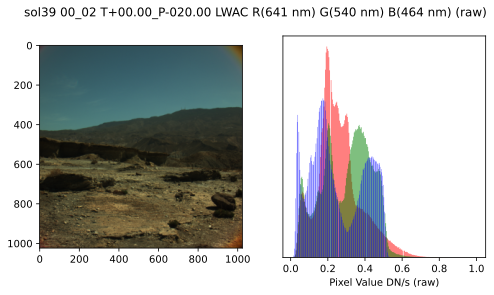

(<Figure size 800x400 with 2 Axes>,
 array([<Axes: >, <Axes: xlabel='Pixel Value DN/s (raw)'>], dtype=object))

In [11]:
lwac_rgb.show_image('raw', apply_gamma=False)

Stretching image using brightest pixel unbalanced


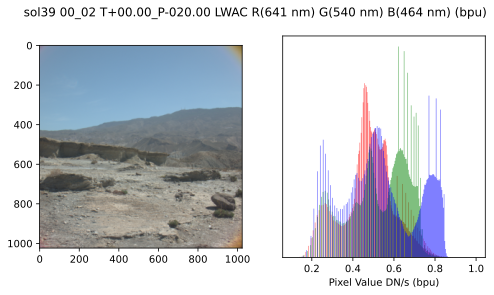

(<Figure size 800x400 with 2 Axes>,
 array([<Axes: >, <Axes: xlabel='Pixel Value DN/s (bpu)'>], dtype=object))

In [12]:
lwac_rgb.show_image('bpu', apply_gamma=True)

Stretching image using brightest pixel balanced


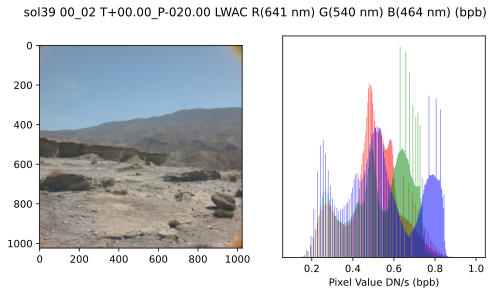

(<Figure size 800x400 with 2 Axes>,
 array([<Axes: >, <Axes: xlabel='Pixel Value DN/s (bpb)'>], dtype=object))

In [13]:
lwac_rgb.show_image('bpb', apply_gamma=True)

Stretching image using 99th percentile balanced


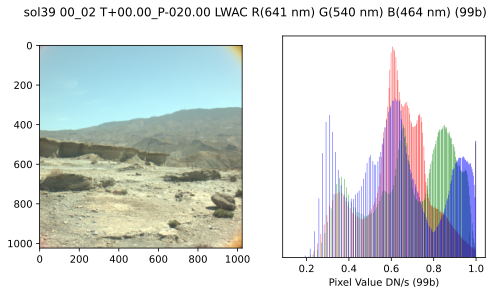

(<Figure size 800x400 with 2 Axes>,
 array([<Axes: >, <Axes: xlabel='Pixel Value DN/s (99b)'>], dtype=object))

In [14]:
lwac_rgb.show_image('99b', apply_gamma=True)

Stretching image using 99th percentile unbalanced


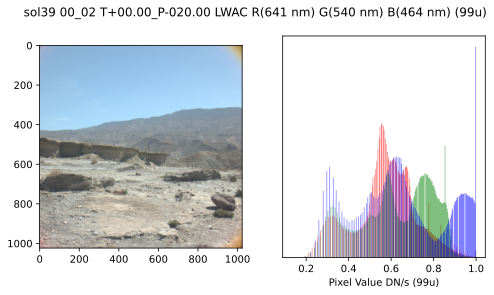

(<Figure size 800x400 with 2 Axes>,
 array([<Axes: >, <Axes: xlabel='Pixel Value DN/s (99u)'>], dtype=object))

In [15]:
lwac_rgb.show_image('99u', apply_gamma=True)

Stretching image using saturattion over minimum exposure time


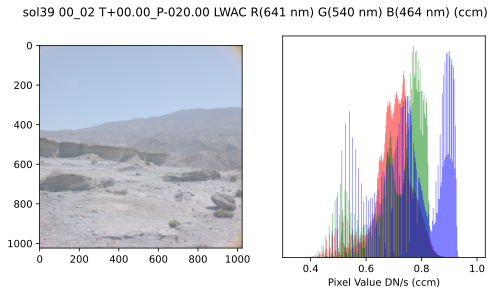

(<Figure size 800x400 with 2 Axes>,
 array([<Axes: >, <Axes: xlabel='Pixel Value DN/s (ccm)'>], dtype=object))

In [16]:
lwac_rgb.show_image('ccm', apply_gamma=True)

The batch script

Let;s get the scene's in here to process.

In [17]:
sol39_aupy_content = [p.name for p in sol39_aupy_path.glob('*/*')]
sol39_aupy_content

['sol39_00_02_T+00.00_P+080.00',
 'sol39_00_02_T+00.00_P-080.00',
 '.DS_Store',
 'sol39_00_02_T+00.00_P+180.00',
 'sol39_00_02_T+71.00_P-124.00',
 'sol39_00_02_RGB_BPU',
 'sol39_00_02_T+70.00_P-077.50',
 'sol39_00_02_T+00.00_P-060.00',
 'sol39_00_02_T+00.00_P+000.00',
 'sol39_00_02_T+00.00_P+020.00',
 'sol39_00_02_T+00.00_P-040.00',
 'sol39_00_02_T+00.00_P-100.00',
 'sol39_00_02_T+00.00_P+060.00',
 'sol39_00_02_T+00.00_P+040.00',
 'sol39_00_02_T+00.00_P+100.00',
 'sol39_00_02_T+00.00_P-020.00',
 '.DS_Store',
 'sol39_00_00_T+71.00_P-069.50',
 'sol39_00_00_T+71.00_P-124.00',
 'sol39_00_00_T+05.04_P+040.47']

In [18]:
sol39_aupy_scenes = [p for p in sol39_aupy_path.glob('*/*')]
# drop .DS_Store files
sol39_aupy_scenes = [p for p in sol39_aupy_scenes if p.name != '.DS_Store']

In [19]:
sol39_aupy_scenes

[PosixPath('/Users/sci/Documents/Documents - Roger’s MacBook Air/projects/esaskp_2025-2027/field_trials/SKP_FT1/data/processing/sol39/aupy/sol39_00_02/sol39_00_02_T+00.00_P+080.00'),
 PosixPath('/Users/sci/Documents/Documents - Roger’s MacBook Air/projects/esaskp_2025-2027/field_trials/SKP_FT1/data/processing/sol39/aupy/sol39_00_02/sol39_00_02_T+00.00_P-080.00'),
 PosixPath('/Users/sci/Documents/Documents - Roger’s MacBook Air/projects/esaskp_2025-2027/field_trials/SKP_FT1/data/processing/sol39/aupy/sol39_00_02/sol39_00_02_T+00.00_P+180.00'),
 PosixPath('/Users/sci/Documents/Documents - Roger’s MacBook Air/projects/esaskp_2025-2027/field_trials/SKP_FT1/data/processing/sol39/aupy/sol39_00_02/sol39_00_02_T+71.00_P-124.00'),
 PosixPath('/Users/sci/Documents/Documents - Roger’s MacBook Air/projects/esaskp_2025-2027/field_trials/SKP_FT1/data/processing/sol39/aupy/sol39_00_02/sol39_00_02_RGB_BPU'),
 PosixPath('/Users/sci/Documents/Documents - Roger’s MacBook Air/projects/esaskp_2025-2027/fie

In [20]:
scene.parent

NameError: name 'scene' is not defined

In [ ]:
# import shutil

# collection_dirname = 'rgb_bpu'

# out_filepaths = []
# for scene in sol39_aupy_scenes:
#     print(scene)
#     # process LWAC
#     lwac_loader = aupy.AupeIO('LWAC', 'RGB', scene)
#     if lwac_loader.input_files != []:
#         lwac_rgb = lwac_loader.load_frame()
#         out_filepath = lwac_rgb.export_image('bpu', apply_gamma=True)
#         # copy to new dir from scene parent
#         new_dir = (scene.parent.stem + '_' + collection_dirname)
#         (scene.parent / new_dir).mkdir(parents=True, exist_ok=True)
#         print(f'copying {out_filepath} to {scene.parent / collection_dirname / out_filepath.name}')
#         shutil.copy2(out_filepath, scene.parent / new_dir / out_filepath.name)
#     else:
#         print(f"No input files found for scene: {scene}")

/Users/sci/Documents/Documents - Roger’s MacBook Air/projects/esaskp_2025-2027/field_trials/SKP_FT1/data/processing/sol39/aupy/sol39_00_02/sol39_00_02_T+00.00_P+080.00
Exporting image using brightest pixel unbalanced
Stretching image using brightest pixel unbalanced
copying /Users/sci/Documents/Documents - Roger’s MacBook Air/projects/esaskp_2025-2027/field_trials/SKP_FT1/data/processing/sol39/aupy/sol39_00_02/sol39_00_02_T+00.00_P+080.00/raw/../LWAC/RGB/sol39_00_02_T+00.00_P+080.00_LWAC_RGB_L1RL2GL3B_bpu.png to /Users/sci/Documents/Documents - Roger’s MacBook Air/projects/esaskp_2025-2027/field_trials/SKP_FT1/data/processing/sol39/aupy/sol39_00_02/rgb_bpu/sol39_00_02_T+00.00_P+080.00_LWAC_RGB_L1RL2GL3B_bpu.png
/Users/sci/Documents/Documents - Roger’s MacBook Air/projects/esaskp_2025-2027/field_trials/SKP_FT1/data/processing/sol39/aupy/sol39_00_02/sol39_00_02_T+00.00_P-080.00
Exporting image using brightest pixel unbalanced
Stretching image using brightest pixel unbalanced
copying /Use

We can also try and patch apply across all sols and scenes

In [23]:
pr_dir
# get sol dirs
sol_dirs = list(pr_dir.glob('sol*'))
sol_dirs

[PosixPath('/Users/sci/Documents/Documents - Roger’s MacBook Air/projects/esaskp_2025-2027/field_trials/SKP_FT1/data/processing/sol38'),
 PosixPath('/Users/sci/Documents/Documents - Roger’s MacBook Air/projects/esaskp_2025-2027/field_trials/SKP_FT1/data/processing/sol07'),
 PosixPath('/Users/sci/Documents/Documents - Roger’s MacBook Air/projects/esaskp_2025-2027/field_trials/SKP_FT1/data/processing/sol39'),
 PosixPath('/Users/sci/Documents/Documents - Roger’s MacBook Air/projects/esaskp_2025-2027/field_trials/SKP_FT1/data/processing/sol06'),
 PosixPath('/Users/sci/Documents/Documents - Roger’s MacBook Air/projects/esaskp_2025-2027/field_trials/SKP_FT1/data/processing/sol41'),
 PosixPath('/Users/sci/Documents/Documents - Roger’s MacBook Air/projects/esaskp_2025-2027/field_trials/SKP_FT1/data/processing/sol40'),
 PosixPath('/Users/sci/Documents/Documents - Roger’s MacBook Air/projects/esaskp_2025-2027/field_trials/SKP_FT1/data/processing/sol04'),
 PosixPath('/Users/sci/Documents/Document

In [ ]:
import shutil

for sol_dir in sol_dirs:
    sol_aupy_dir = sol_dir / 'aupy'

    # drop .DS_Store files
    sol_scenes = [p for p in sol_aupy_dir.glob('*/*') if p.name != '.DS_Store']
    # drop sol_scenes if it contains 'RGB'
    sol_scenes = [p for p in sol_scenes if 'RGB' not in p.name]

    # if the sol_scene

    collection_dirname = 'RGB_99U'

    out_filepaths = []
    for scene in sol_scenes:
        print(scene.stem)
        # process LWAC
        lwac_loader = aupy.AupeIO('LWAC', 'RGB', scene)
        if lwac_loader.input_files != []:
            lwac_rgb = lwac_loader.load_frame()
            lwac_rgb.exposure_correct()
            # correct ex
            out_filepath = lwac_rgb.export_image('99u', apply_gamma=True)
            # copy to new dir from scene parent
            new_dir = (scene.parent.stem + '_' + collection_dirname)
            (scene.parent / new_dir).mkdir(parents=True, exist_ok=True)
            print(f'copying {str(out_filepath.stem)} to {str(scene.parent.stem)}/{collection_dirname}/{out_filepath.name}')
            shutil.copy2(out_filepath, scene.parent / new_dir / out_filepath.name)
            
        else:
            print(f"No input files found for scene: {scene}")

/opt/homebrew/Caskroom/miniconda/base/envs/aupy_dev/lib/python3.13/site-packages/IPython/extensions/deduperreload/deduperreload.py:290: DeprecationWarning: ast.Ellipsis is deprecated and will be removed in Python 3.14; use ast.Constant instead
  elif not isinstance(ast_elt, (ast.Ellipsis, ast.Pass)):
/opt/homebrew/Caskroom/miniconda/base/envs/aupy_dev/lib/python3.13/site-packages/IPython/extensions/deduperreload/deduperreload.py:290: DeprecationWarning: ast.Ellipsis is deprecated and will be removed in Python 3.14; use ast.Constant instead
  elif not isinstance(ast_elt, (ast.Ellipsis, ast.Pass)):
/opt/homebrew/Caskroom/miniconda/base/envs/aupy_dev/lib/python3.13/site-packages/IPython/extensions/deduperreload/deduperreload.py:290: DeprecationWarning: ast.Ellipsis is deprecated and will be removed in Python 3.14; use ast.Constant instead
  elif not isinstance(ast_elt, (ast.Ellipsis, ast.Pass)):
/opt/homebrew/Caskroom/miniconda/base/envs/aupy_dev/lib/python3.13/site-packages/IPython/exten

sol38_02_01_T+71.00_P-124
Exporting image using 99th percentile unbalanced
Stretching image using 99th percentile unbalanced
copying sol38_02_01_T+71.00_P-124.00_LWAC_RGB_L1RL2GL3B_99u to sol38_02_01/RGB_99U/sol38_02_01_T+71.00_P-124.00_LWAC_RGB_L1RL2GL3B_99u.png
sol38_02_01_T+71.00_P-069
No input files found for scene: /Users/sci/Documents/Documents - Roger’s MacBook Air/projects/esaskp_2025-2027/field_trials/SKP_FT1/data/processing/sol38/aupy/sol38_02_01/sol38_02_01_T+71.00_P-069.50/raw
No input files found for scene: /Users/sci/Documents/Documents - Roger’s MacBook Air/projects/esaskp_2025-2027/field_trials/SKP_FT1/data/processing/sol38/aupy/sol38_02_01/sol38_02_01_T+71.00_P-069.50
sol38_01_01_T+15.00_P+050
Exporting image using 99th percentile unbalanced
Stretching image using 99th percentile unbalanced
copying sol38_01_01_T+15.00_P+050.00_LWAC_RGB_L1RL2GL3B_99u to sol38_01_01/RGB_99U/sol38_01_01_T+15.00_P+050.00_LWAC_RGB_L1RL2GL3B_99u.png
sol38_01_01_T+15.00_P+025
Exporting image 

We can also batch make a mosaic

In [32]:
import cv2
import os

# Load images from a directory or list
def mosaic_stitcher(image_paths, scene_dir):
    images = [cv2.imread(p) for p in image_paths]

    # Create the stitcher and process images
    stitcher = cv2.Stitcher_create()
    status, mosaic = stitcher.stitch(images)

    if status == cv2.Stitcher_OK:
        cv2.imwrite(os.path.join(scene_dir, "mosaic_output.jpg"), mosaic)
        print("Mosaic created successfully!")
    else:
        print("Stitching failed with error code:", status)

In [33]:
for sol_dir in sol_dirs:
    sol_aupy_dir = sol_dir / 'aupy'

    # drop .DS_Store files
    sol_scenes = [p for p in sol_aupy_dir.glob('*/*') if p.name != '.DS_Store']
    # drop sol_scenes if it contains 'RGB'
    sol_scenes = [p for p in sol_scenes if 'RGB' in p.name]

    for sol_scene in sol_scenes:
        print(sol_scene.stem)
        # get all images in the sol_scene directory
        image_paths = [p for p in sol_scene.glob('*.png')]
        if image_paths:
            mosaic_stitcher(image_paths, sol_scene)

sol38_02_01_RGB_BPU
Stitching failed with error code: 1
sol38_02_01_RGB_99U
Stitching failed with error code: 1
sol38_01_01_RGB_99U
Mosaic created successfully!
sol38_01_01_RGB_BPU
Mosaic created successfully!
sol39_00_02_RGB_99U
Mosaic created successfully!
sol39_00_02_RGB_BPU
Mosaic created successfully!
sol4_02_01_RGB_BPU
Stitching failed with error code: 1
sol4_02_01_RGB_99U
Stitching failed with error code: 1
sol4_01_01_RGB_99U
Stitching failed with error code: 3
sol4_01_01_RGB_BPU
Mosaic created successfully!
